In [1]:
# Load required modules
#%matplotlib inline

#from IPython.display import display

import numpy as np


from PIL import Image


#For plotting
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.rcParams["animation.html"] = "jshtml"
mpl.rcParams['figure.facecolor'] = 'white'

# Import relevant modules from within GPU Ocean
from gpuocean.SWEsimulators import GPUOceanSim
from gpuocean.utils import IPythonMagic, NetCDFInitialization, PlotHelper, DrifterPlotHelper
from gpuocean.utils import Common, BathymetryAndICs
from gpuocean.drifters import LagrangianUtils

# Need pycuda to do things from scratch
import pycuda.driver as cuda


from importlib import reload

In [2]:
# Create the GPU context
%cuda_context_handler gpu_ctx

In [3]:
def imshow1(data, title=""):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", origin='lower', 
                            cmap=plt.cm.BrBG, vmin=-data_max, vmax=data_max)
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

In [4]:
def imshow_image(data, title=""):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", vmin= np.min(data), vmax= np.max(data))
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

(365, 1103)


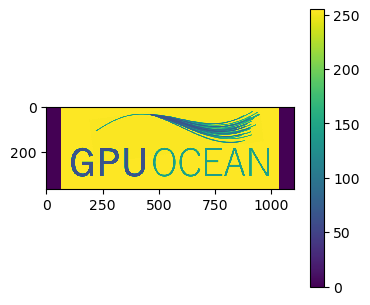

In [5]:
# Load the image
image_path = '../logo\gpuocean-logo.png'  # Replace with your image file path
input_image = Image.open(image_path)

# Convert the image to grayscale
gray_image = input_image.convert('L')

# Convert the grayscale image to a numpy array
image_array = np.array(gray_image)
print(image_array.shape)
imshow_image(image_array)


Test table lookup of exact values

(60, 60)


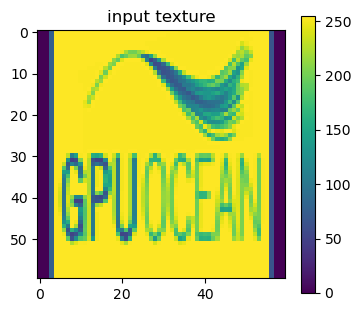

In [6]:
# Define a small domain 
nx, ny = 60, 60

nx_tex, ny_tex = 60, 60

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture")

In [7]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

c:\Users\jakobt\AppData\Local\miniconda3\envs\gpuocean\lib\site-packages\ipykernel_launcher.py:32: UserWarning: The CUDA compiler succeeded, but said the following:
kernel.cu



In [8]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [9]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(60, 60)
(60, 60)
(60, 60)
(60, 60)


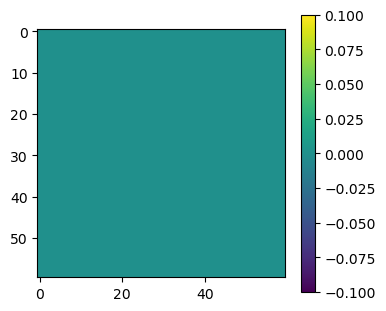

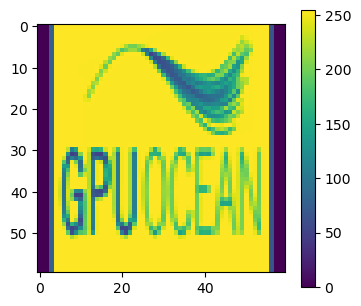

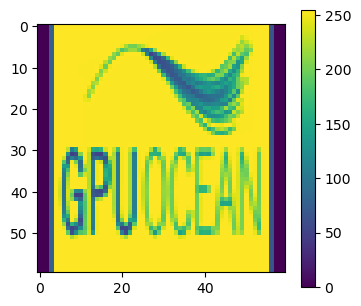

In [10]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

imshow_image(image_init)
imshow_image(image_host)
imshow_image(tex_image_host)

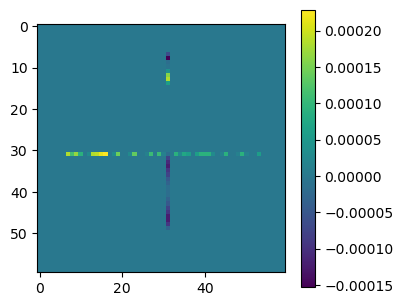

In [11]:
diff = image_host - tex_image_host
imshow_image(diff)

5.276998e-07


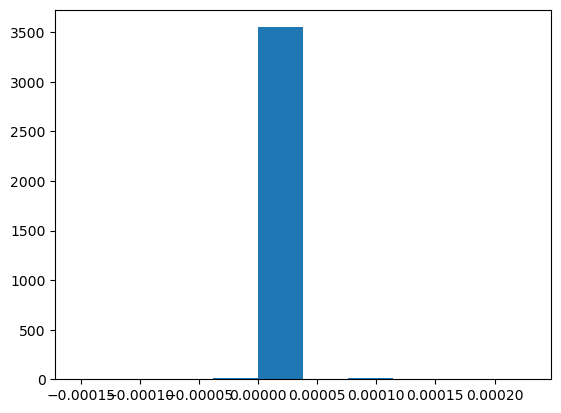

In [12]:
plt.hist(diff.flatten())
print(diff.mean())

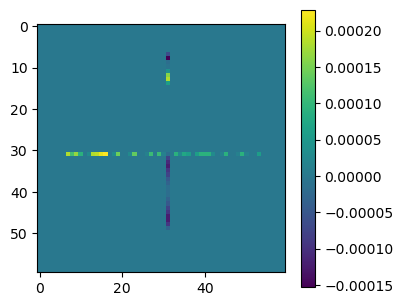

In [13]:
diff2 = image_host - original_image
imshow_image(diff2)

5.276998e-07


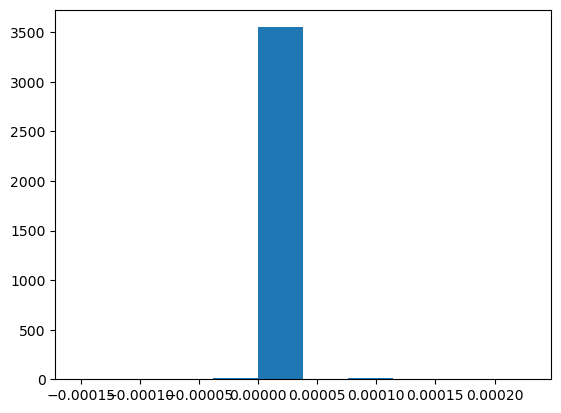

In [14]:
plt.hist(diff2.flatten())
print(diff2.mean())

Test downsampling

(60, 60)


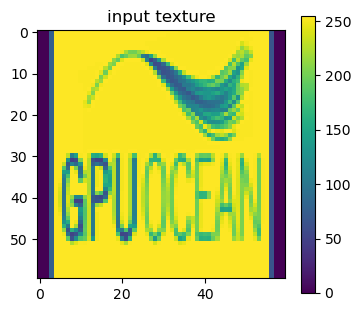

In [15]:
# Define a small domain 
nx, ny = 30, 30

nx_tex, ny_tex = 60, 60

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture")

In [16]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [17]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [18]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(30, 30)
(30, 30)
(30, 30)
(30, 30)


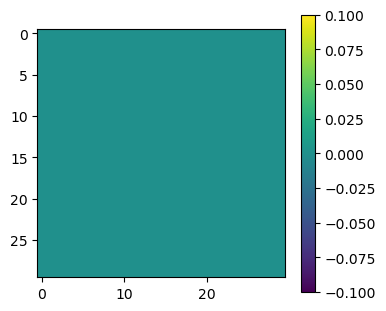

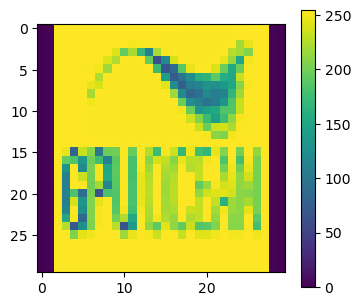

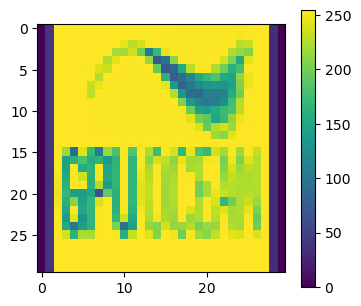

In [19]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

imshow_image(image_init)
imshow_image(image_host)
imshow_image(tex_image_host)

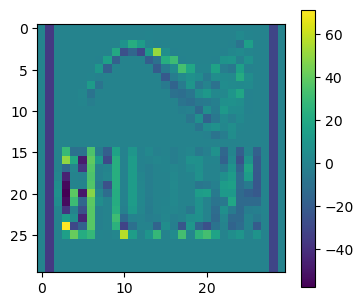

In [20]:
diff = image_host - tex_image_host
imshow_image(diff)

-1.5747064


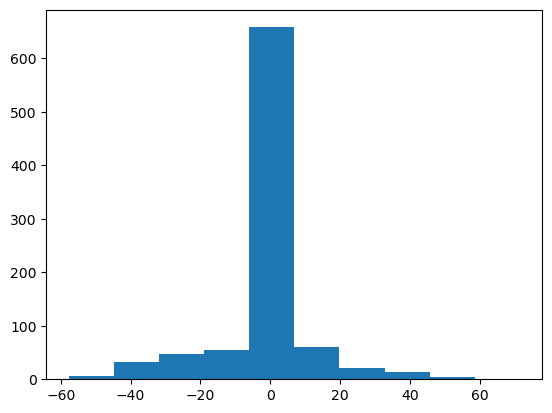

In [21]:
plt.hist(diff.flatten())
print(diff.mean())

Test upsampling

(30, 30)


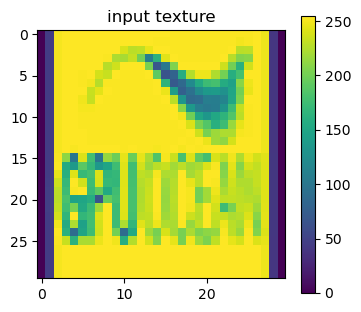

In [22]:
# Define a small domain 
nx, ny = 60, 60

nx_tex, ny_tex = 30, 30

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
test_image = gray_image.resize((nx, ny))
tex_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture")

In [23]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [24]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [25]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(60, 60)
(60, 60)
(60, 60)
(60, 60)


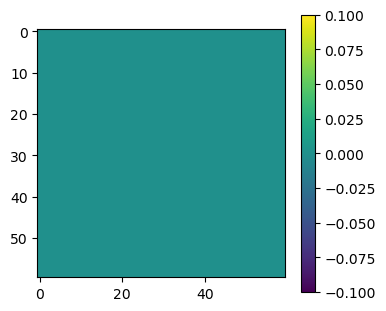

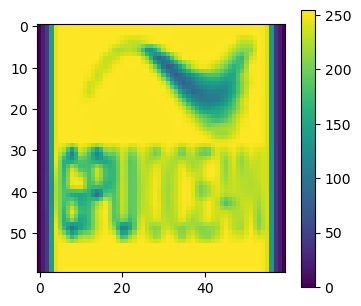

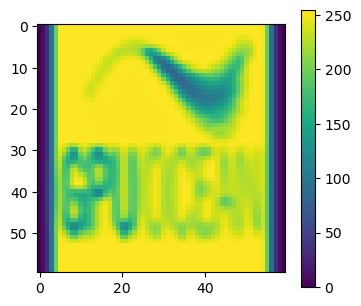

In [26]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

imshow_image(image_init)
imshow_image(image_host)
imshow_image(tex_image_host)

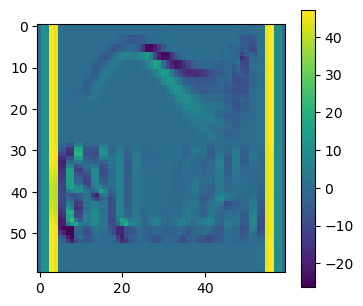

In [27]:
diff = image_host - tex_image_host
imshow_image(diff)

3.1107087


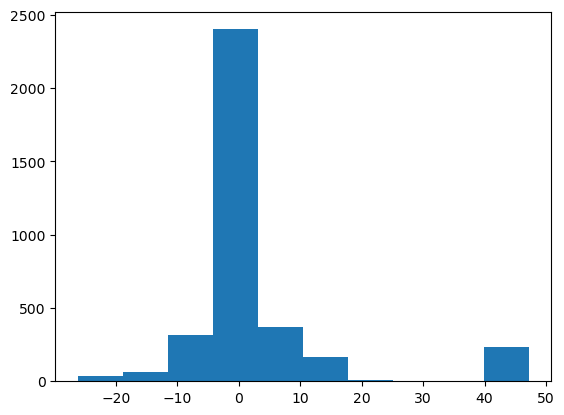

In [28]:
plt.hist(diff.flatten())
print(diff.mean())